# Trajectory Inference Tests

Test the new simulation-based trajectory inference for various pulse sequences.

In [1]:
# Add auto reload:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import lmt_sim.lmt_simulation as sim
import lmt_sim.lmt_sequence as seq
from scipy import constants as scipy_constants
import version_info as vs

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import FixedLocator

In [3]:
pulse_sequence = [[[1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0], [4936, 2691191, 2771190, 2838189, 2918188, 2985187, 3065186, 3132185, 3212184, 3279183, 3359182, 3426181, 3506180, 3573179, 3653178, 3720177, 3800176, 4077207, 4122991, 4286111, 4392695, 4722709, 4809244, 4922367, 5030207, 5108734, 5221855, 5328439, 5508438, 5594973, 5908111, 6019623], [380000, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 34000, 99999, 99999, 68000, 68000, 99999, 99999, 68000, 99999, 99999, 68000, 68000, 99999, 99999, 34000], [80000000, 79971814, 80020109, 79988550, 80003372, 80005286, 79986636, 80022022, 79969900, 80038758, 79953164, 80055494, 79936428, 80072230, 79919692, 80088966, 79902956, 80027353, 79983322, 79966812, 80004123, 79999490, 79974157, 79994546, 80013772, 79978362, 79998751, 80028585, 80026058, 80003989, 79989586, 80000149], [200000000, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200000500, 200000500, 200005800, 200005800, 200000500, 200000500, 200005800, 200000500, 200000500, 200005800, 200005800, 200000500, 200000500, 200005800], [99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300], [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]]]

In [4]:
(
    is_up,
    start_times_mu,
    durations_mu,
    opll_hz,
    switch_hz,
    delivery_hz,
    delivery_setpoint
) = pulse_sequence[0]

is_up = np.array(is_up)
start_times_mu = np.array(start_times_mu)
durations_mu = np.array(durations_mu)
opll_hz = np.array(opll_hz)
switch_hz = np.array(switch_hz)
delivery_hz = np.array(delivery_hz)
delivery_setpoint = np.array(delivery_setpoint)

In [5]:
# Manually specify which durations are pi pulses and which are pi/2
is_pi_pulse = lambda d: d > 50000e-9

In [6]:
# Cut after the launch

t_launch_finished = 5e-3

is_before_launch = start_times_mu * 1e-9 < t_launch_finished

is_up = is_up[is_before_launch]
start_times_mu = start_times_mu[is_before_launch]
durations_mu = durations_mu[is_before_launch]
opll_hz = opll_hz[is_before_launch]
switch_hz = switch_hz[is_before_launch]
delivery_hz = delivery_hz[is_before_launch]
delivery_setpoint = delivery_setpoint[is_before_launch]

In [7]:
# --- HACKY AUTO-CALIBRATION (a warning is emitted at runtime) ---
# alpha (probe-shift coefficient) and v0 (initial atom velocity) used to be
# hand-tuned magic numbers. Instead we now back them out of the lab pulse dump:
# alpha from how the up-beam pulses sit relative to each other vs their Rabi
# frequency, and v0 from the residual up/down detuning once alpha is applied.
# This is a self-consistent fit, NOT a measurement -- replace with real
# light-shift and launch-velocity calibrations.
# probe_shift_alpha, initial_velocity_z = (
#     seq.calibrate_probe_shift_and_velocity_from_dump(
#         is_up=is_up,
#         start_times_mu=start_times_mu,
#         durations_mu=durations_mu,
#         opll_hz=opll_hz,
#         switch_hz=switch_hz,
#         delivery_hz=delivery_hz,
#         delivery_setpoint=delivery_setpoint,
#     )
# )


t_pi_ref = 55e-6


# From measurement - see "2026-06-09 Clock shift gap-filling even Omega2 grid"
# The measurement defined alpha in terms of 1/ (rad/s), so convert to 1/Hz
probe_shift_alpha = -2.04e-6 * (2 * np.pi)
print(f"calibrated probe-shift alpha = {probe_shift_alpha:.4e} Hz^-1")

rabi_freq_ref = 1 / (2*t_pi_ref)
probe_shift_ref = probe_shift_alpha * rabi_freq_ref**2
print(f"corresponding probe shift at Rabi frequency {rabi_freq_ref:.1f} Hz is {probe_shift_ref:.1f} Hz")


calibrated probe-shift alpha = -1.2818e-05 Hz^-1
corresponding probe shift at Rabi frequency 9090.9 Hz is -1059.3 Hz


In [8]:
# Pick the first down pulse and set the initial_velocity_z such that it's resonant
# FIXME
initial_velocity_z = -1.6e-3

In [9]:
_, sequence = seq.build_sequence_from_lab_pulse_dump(
    is_up=is_up,
    start_times_mu=start_times_mu,
    durations_mu=durations_mu,
    opll_hz=opll_hz,
    switch_hz=switch_hz,
    delivery_hz=delivery_hz,
    delivery_setpoint=delivery_setpoint,
    initial_velocity_z=initial_velocity_z,
    probe_induced_alpha_up=probe_shift_alpha,
    probe_induced_alpha_down=probe_shift_alpha,
)


## Mark the first up pulse as a shaped pulse

The first up pulse (380 us) is a shaped (quantum-optimal-control) velocity-selection
pulse. The details of how it works are out of scope: we model it as a plain pi pulse.
`build_sequence_from_lab_pulse_dump` therefore inferred a fictitious Rabi frequency
`1/(2*duration)` ~ 1.3 kHz from its duration -- but its true intensity (and therefore
its probe-induced Stark shift) corresponds to the same Rabi frequency as the ordinary
up pi pulses (~9.1 kHz). Setting `stark_rabi_frequency` tells the sim to compute the
light shift from the true Rabi frequency while keeping the pretend-pi-pulse dynamics.

Because the shaped pulse is the **first** pulse, the parser also anchored the centre
frequency on it using the fictitious Rabi frequency, so every detuning in the sequence
inherits the error in its probe shift. We re-derive the anchor with the true Rabi
frequency by shifting all detunings by `alpha * (rabi_true**2 - rabi_fictitious**2)`.

In [10]:
import dataclasses
from collections import Counter

pulses = [e for e in sequence if isinstance(e, seq.Pulse)]
shaped_pulse = pulses[0]
assert shaped_pulse.k == +1 and shaped_pulse.duration > 300e-6

rabi_counts = Counter(p.rabi_frequency for p in pulses[1:] if p.k == +1)
print("Rabi frequencies inferred for the other up pulses:")
for rabi, count in sorted(rabi_counts.items()):
    print(f"  {rabi:8.1f} Hz x {count}")
true_up_rabi = rabi_counts.most_common(1)[0][0]
print(f"-> using the most common as the shaped pulse's true Rabi: {true_up_rabi:.1f} Hz")
assert np.isclose(true_up_rabi, rabi_freq_ref, rtol=1e-3)

# The dump parser anchored the centre frequency on the first pulse being
# resonant after removing ITS probe shift -- computed from the fictitious
# duration-implied Rabi frequency. Re-derive the anchor with the true Rabi
# frequency: every detuning shifts by the difference in the first pulse's shift.
anchor_correction_hz = probe_shift_alpha * (
    true_up_rabi**2 - shaped_pulse.rabi_frequency**2
)
print(
    f"centre-frequency anchor correction: {anchor_correction_hz:+.1f} Hz "
    f"({anchor_correction_hz / sim.RECOIL_FREQUENCY_HZ:+.3f} recoils), "
    "applied to every pulse"
)

sequence = [
    (
        event
        if not isinstance(event, seq.Pulse)
        else dataclasses.replace(
            event,
            detuning_hz=event.detuning_hz + anchor_correction_hz,
            stark_rabi_frequency=true_up_rabi if event is shaped_pulse else None,
        )
    )
    for event in sequence
]


Rabi frequencies inferred for the other up pulses:
    5000.1 Hz x 4
    9091.1 Hz x 8
-> using the most common as the shaped pulse's true Rabi: 9091.1 Hz
centre-frequency anchor correction: -1037.2 Hz (-0.220 recoils), applied to every pulse


In [11]:
def plot_lab_pulse_sequence(plot_sequence, plot_corrected=True, plot_by_timestamp=False):
    raw_detunings_recoil = []
    corrected_detunings_recoil = []
    pulse_colours = []
    pulse_hatches = []
    clearout_links = []

    last_pulse_index = None
    clearout_since_last_pulse = False

    PULSE_STYLES = {
        #              colour          hatch
        (True, True): ("tab:orange", ""),  # up,   pi
        (True, False): ("tab:blue", "///"),  # up,   pi/2
        (False, True): ("tab:red", "\\\\"),  # down, pi
        (False, False): ("tab:purple", "xxx"),  # down, pi/2
    }

    timestamps = []
    pulse_durations = []
    now = 0.0
    for event in plot_sequence:
        if isinstance(event, seq.Clearout):
            clearout_since_last_pulse = True
            now += event.duration
            continue

        if not isinstance(event, seq.Pulse):
            now += event.duration
            continue

        timestamps.append(now + event.duration / 2)
        pulse_durations.append(event.duration)
        now += event.duration

        pulse_index = len(raw_detunings_recoil)
        raw_detunings_recoil.append(event.detuning_hz / sim.RECOIL_FREQUENCY_HZ)
        probe_shift_hz = (
            event.probe_shift_coefficient * event.effective_stark_rabi_frequency**2
        )
        corrected_detunings_recoil.append(
            (event.detuning_hz - probe_shift_hz) / sim.RECOIL_FREQUENCY_HZ
        )

        colour, hatch = PULSE_STYLES[(event.k == 1, is_pi_pulse(event.duration))]
        pulse_colours.append(colour)
        pulse_hatches.append(hatch)

        if last_pulse_index is not None and clearout_since_last_pulse:
            clearout_links.append((last_pulse_index, pulse_index))

        last_pulse_index = pulse_index
        clearout_since_last_pulse = False

    pulse_indices = np.arange(len(raw_detunings_recoil))

    fig, ax = plt.subplots(figsize=(18, 10))
    plot_detunings = (
        corrected_detunings_recoil if plot_corrected else raw_detunings_recoil
    )

    x_axis = timestamps if plot_by_timestamp else pulse_indices

    bars = ax.bar(x_axis, plot_detunings, color=pulse_colours, width= pulse_durations if plot_by_timestamp else 0.9)
    for bar, hatch in zip(bars, pulse_hatches):
        bar.set_hatch(hatch)

    for left_index, right_index in clearout_links:
        ax.plot(
            [x_axis[left_index], x_axis[right_index]],
            [
                plot_detunings[left_index],
                plot_detunings[right_index],
            ],
            color="tab:green",
            linestyle=":",
            linewidth=2,
            zorder=3,
        )

    if not plot_by_timestamp:
        tick_step = max(1, len(pulse_indices) // 20)
        ax.set_xticks(pulse_indices[::tick_step])
        ax.set_xlabel("Pulse index")
    else:
        ax.set_xlabel("Time (s)")
    ax.set_ylabel("Detuning (recoil frequencies)")

    # Show where the uncorrected (raw) detuning sat, for comparison.
    if plot_corrected:
        ax.scatter(
            x_axis,
            raw_detunings_recoil,
            facecolor="none",
            edgecolor="0.2",
            marker="o",
            s=40,
            zorder=4,
        )

    # Horizontal gridlines on the odd integers only.
    y_min, y_max = ax.get_ylim()
    odd_integers = np.arange(np.ceil(y_min), np.floor(y_max) + 1)
    odd_integers = odd_integers[odd_integers % 2 != 0]
    for y in odd_integers:
        ax.axhline(y, color="0.5", linestyle=":", alpha=0.8, zorder=0)
    ax.axhline(0.0, color="0.5", linestyle="-", alpha=0.8, zorder=0)

    legend_handles = [
        Patch(facecolor="tab:orange", hatch="", label="up, pi"),
        Patch(facecolor="tab:blue", hatch="///", label="up, pi/2"),
        Patch(facecolor="tab:red", hatch="\\\\", label="down, pi"),
        Patch(facecolor="tab:purple", hatch="xxx", label="down, pi/2"),
    ]
    if clearout_links:
        legend_handles.append(
            Line2D(
                [0],
                [0],
                color="tab:green",
                linestyle=":",
                linewidth=2,
                label="clearout between pulses",
            )
        )

    ax.legend(handles=legend_handles, loc="upper left", frameon=False)

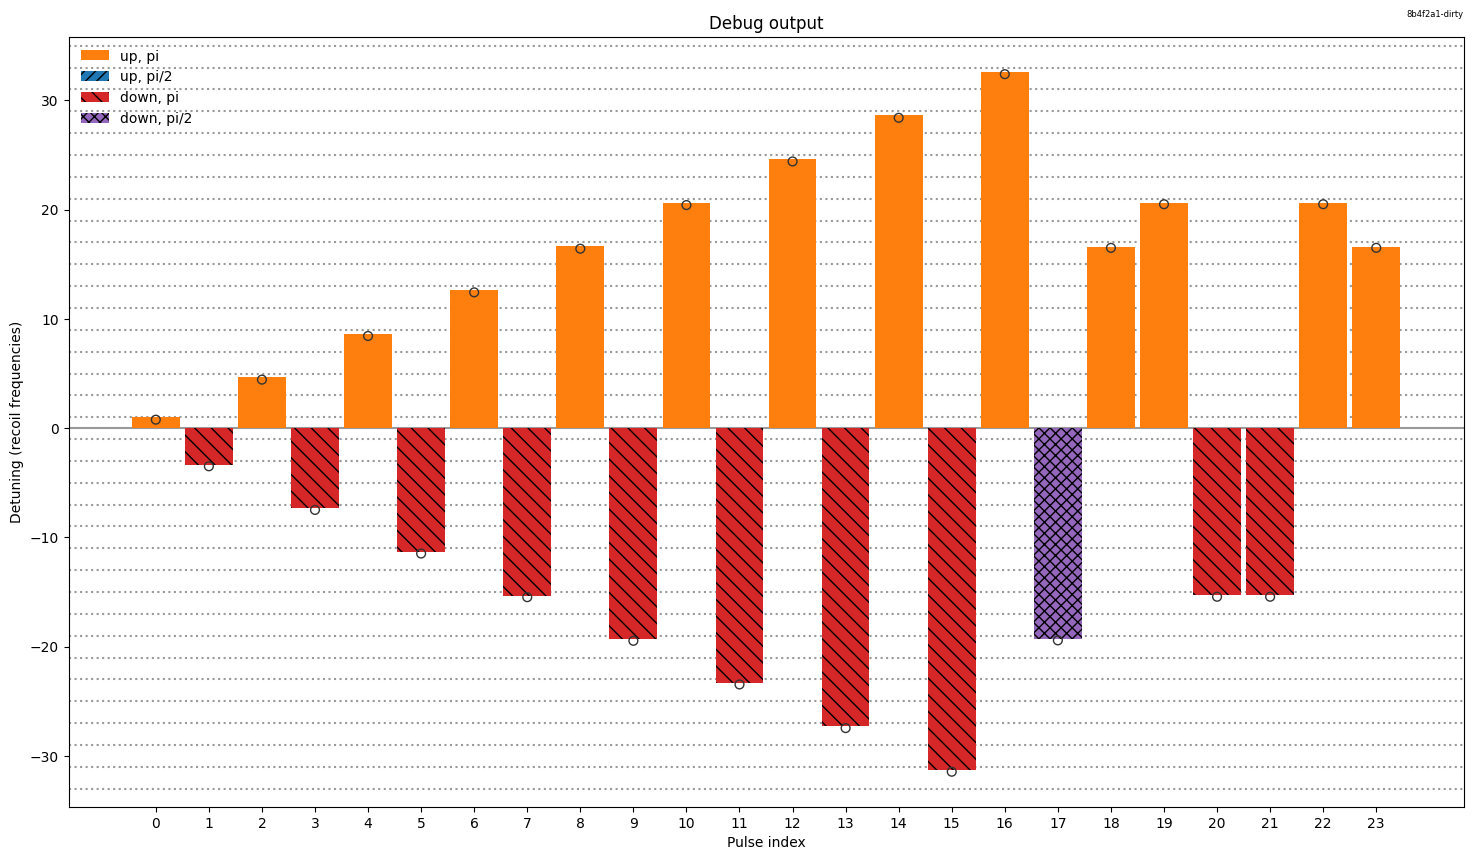

In [12]:
plot_lab_pulse_sequence(sequence, plot_corrected=True)
plt.title("Debug output")
vs.tag_plot(small=True);

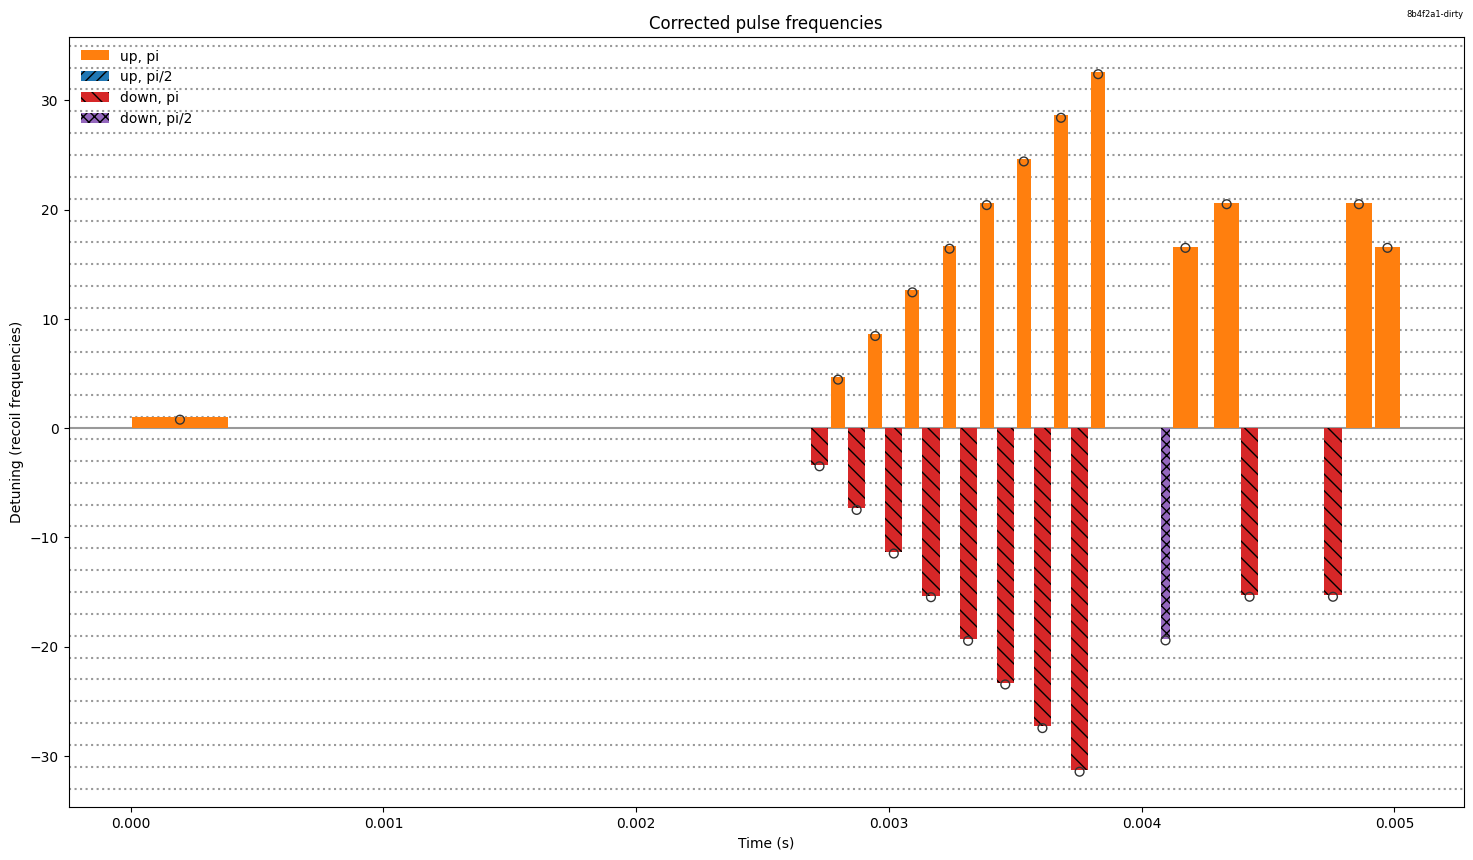

In [13]:
plot_lab_pulse_sequence(sequence, plot_corrected=True, plot_by_timestamp=True)
plt.title("Corrected pulse frequencies")
vs.tag_plot(small=True);

([compute_spacetime_trajectory.<locals>.Cloud(times=[0.0, np.float64(4.936000000000001e-06), np.float64(0.000384936), np.float64(0.002691191), np.float64(0.002759191), np.float64(0.0027711899999999998), np.float64(0.002826189), np.float64(0.0028381889999999996), np.float64(0.0029061889999999996), np.float64(0.002918188), np.float64(0.002973187), np.float64(0.002985187), np.float64(0.0030531869999999997), np.float64(0.0030651859999999997), np.float64(0.0031201849999999997), np.float64(0.0031321849999999996), np.float64(0.0032001849999999995), np.float64(0.003212184), np.float64(0.003267183), np.float64(0.0032791829999999998), np.float64(0.0033471829999999997), np.float64(0.0033591819999999996), np.float64(0.0034141809999999996), np.float64(0.003426181), np.float64(0.003494181), np.float64(0.00350618), np.float64(0.003561179), np.float64(0.0035731789999999997), np.float64(0.0036411789999999996), np.float64(0.003653178), np.float64(0.003708177), np.float64(0.003720177), np.float64(0.00378

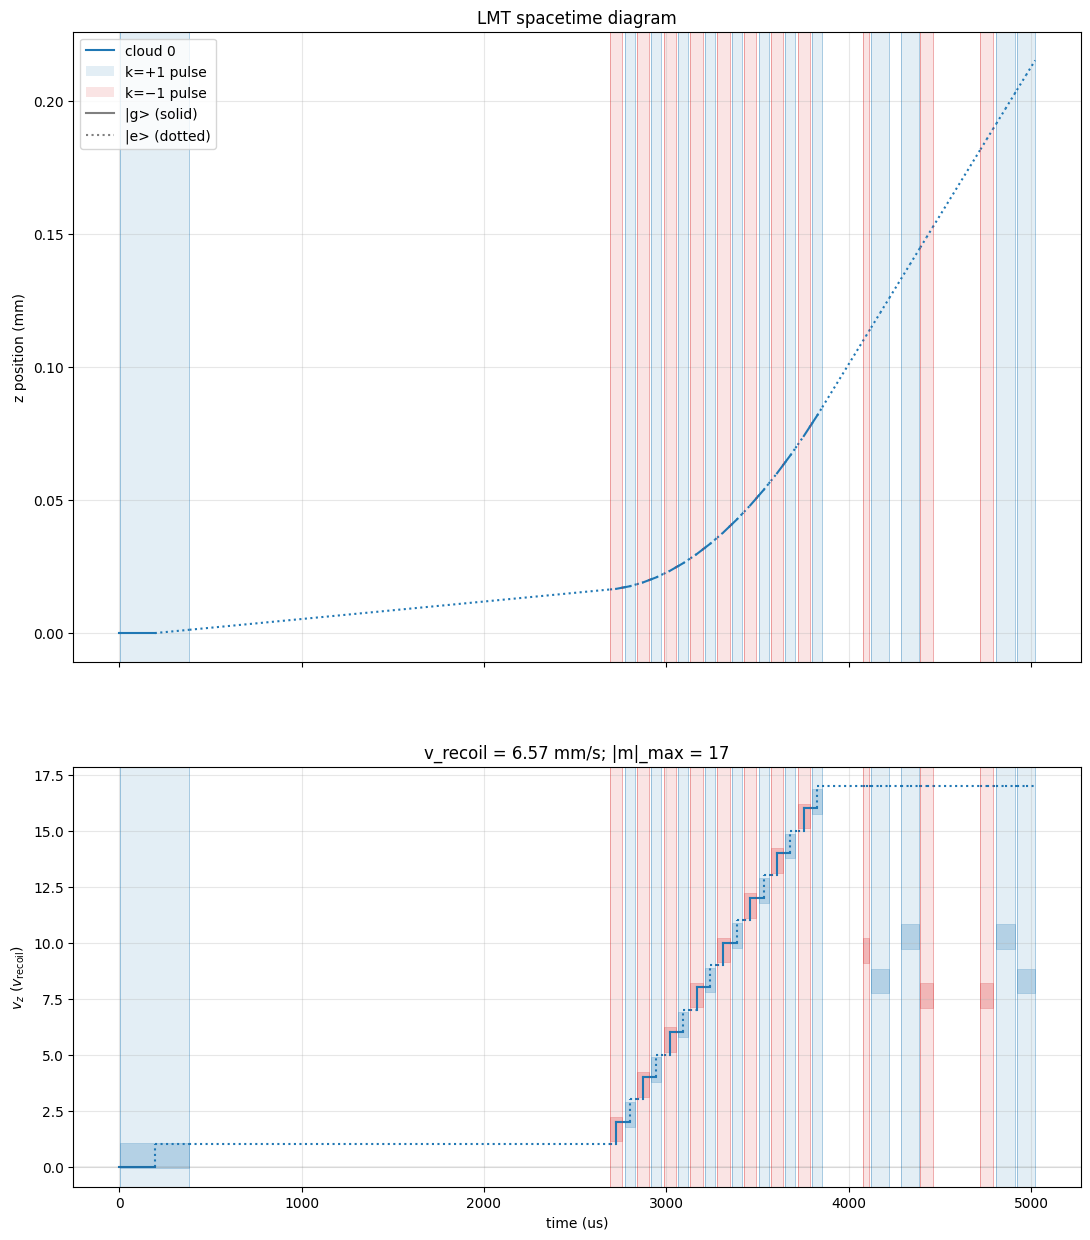

In [14]:
seq.compute_spacetime_trajectory(sequence, plot=True, max_branches=20)

In [15]:
# Apply a hacky correction - round each pulse to the nearest corrected integer number of recoils

bodged_sequence = []
for event in sequence:
    if not isinstance(event, seq.Pulse):
        bodged_sequence.append(event)
        continue

    probe_shift_hz = (
        event.probe_shift_coefficient * event.effective_stark_rabi_frequency**2
    )

    closest_integer = int(
        round((event.detuning_hz - probe_shift_hz) / sim.RECOIL_FREQUENCY_HZ)
    )

    # Re-add the probe shift so that the EFFECTIVE detuning (the sim subtracts
    # the shift again during the pulse) lands exactly on the recoil ladder.
    new_pulse = dataclasses.replace(
        event,
        detuning_hz=closest_integer * sim.RECOIL_FREQUENCY_HZ + probe_shift_hz,
    )
    bodged_sequence.append(new_pulse)


([compute_spacetime_trajectory.<locals>.Cloud(times=[0.0, np.float64(4.936000000000001e-06), np.float64(0.000384936), np.float64(0.002691191), np.float64(0.002759191), np.float64(0.0027711899999999998), np.float64(0.002826189), np.float64(0.0028381889999999996), np.float64(0.0029061889999999996), np.float64(0.002918188), np.float64(0.002973187), np.float64(0.002985187), np.float64(0.0030531869999999997), np.float64(0.0030651859999999997), np.float64(0.0031201849999999997), np.float64(0.0031321849999999996), np.float64(0.0032001849999999995), np.float64(0.003212184), np.float64(0.003267183), np.float64(0.0032791829999999998), np.float64(0.0033471829999999997), np.float64(0.0033591819999999996), np.float64(0.0034141809999999996), np.float64(0.003426181), np.float64(0.003494181), np.float64(0.00350618), np.float64(0.003561179), np.float64(0.0035731789999999997), np.float64(0.0036411789999999996), np.float64(0.003653178), np.float64(0.003708177), np.float64(0.003720177), np.float64(0.00378

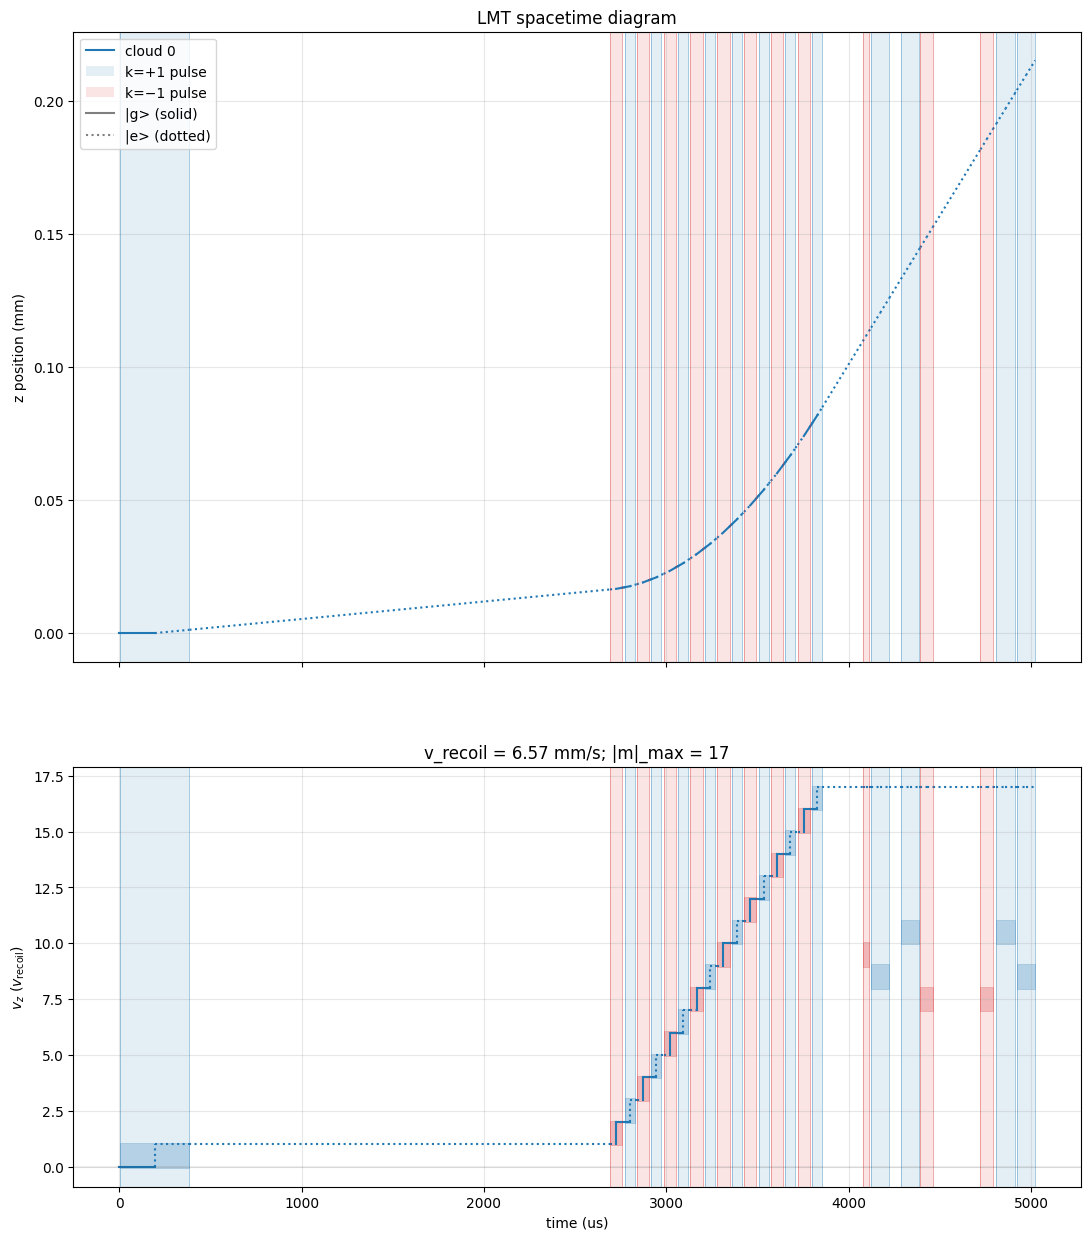

In [16]:
seq.compute_spacetime_trajectory(bodged_sequence, plot=True, max_branches=20)